In [2]:
%load_ext autoreload
%autoreload 2

from pathlib import Path 
import os
os.environ['MUJOCO_GL'] = 'egl'
os.environ['MKL_SERVICE_FORCE_INTEL'] = '1'
from tqdm import tqdm
from IPython.display import Video

import torch
import numpy as np

import sys
sys.path.append("/mnt/home/focus")

os.chdir("/mnt/home/focus")
print(f"Working directory: {os.getcwd()}")

import env
from env.make import make

import matplotlib.pyplot as plt
import matplotlib.animation as animation

/opt/conda/lib/python3.11/site-packages/robosuite/__init__.py:7: DeprecationWarning: The 'warn' method is deprecated, use 'warning' instead
  ROBOSUITE_DEFAULT_LOGGER.warn("No private macro file found!")
[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /opt/conda/lib/python3.11/site-packages/robosuite/scripts/setup_macros.py (__init__.py:9)


Working directory: /mnt/home/focus


/opt/conda/lib/python3.11/site-packages/warp_maniskill/warp/codegen.py:13: DeprecationWarning: the imp module is deprecated in favour of importlib and slated for removal in Python 3.12; see the module's documentation for alternative uses
  import imp
/opt/conda/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: DeprecationWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", DeprecationWarning)


In [3]:
# Import agent model (WM + Actor Critic)
agent_path = Path(f'/mnt/public/projects/mazpie/focus_skill_dmc_sweep_distance_mode_coordConv/pretrained_models/skill_focus/dmc/reacher_hard/1/snapshot_500000.pt')

def load_agent(agent_path):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    with agent_path.open('rb') as f:
        obj = torch.load(f, map_location=torch.device(device))
        agent = obj['agent']    
        step = obj['_global_step']
        agent.device = device
        agent.wm.device = device
        agent.wm.rssm.device = device
        agent.wm.rssm._cell.device = device
        agent.is_finetune = True
    return agent, step

agent, global_step = load_agent(agent_path)

In [4]:
from hydra import compose, initialize
from omegaconf import OmegaConf

initialize(config_path="../../../../public/projects/mazpie/focus_skill_dmc_sweep_distance_mode_coordConv/pretrain/41a31fc2cd0e0ccf75b1449541cc2694/code/exp_local/2024.01.02/143841_skill_focus_reacher_hard_/.hydra", job_name="config")
cfg = compose(config_name="config")

/tmp/ipykernel_826/725984538.py:4: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  initialize(config_path="../../../../public/projects/mazpie/focus_skill_dmc_sweep_distance_mode_coordConv/pretrain/41a31fc2cd0e0ccf75b1449541cc2694/code/exp_local/2024.01.02/143841_skill_focus_reacher_hard_/.hydra", job_name="config")


In [5]:
obs_type = "pixels"
action_repeat = 2
snapshot_ts = global_step * action_repeat
seed = 0

domain = "dmc"  
task = "reacher_hard"

# Env creation
env = make(cfg.domain, cfg.task, obs_type, frame_stack=1, 
                    action_repeat=action_repeat, seed=seed, env_config=cfg.env)

env.reset()

/opt/conda/lib/python3.11/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


final text_encoder_type: bert-base-uncased


Hyperparameters read from the model weights: C^k=64, C^v=512, C^h=64
Single object mode: False


Downloading: "https://download.pytorch.org/models/resnet50-19c8e357.pth" to /tmp/.cache/torch/hub/checkpoints/resnet50-19c8e357.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 148MB/s]
Downloading: "https://download.pytorch.org/models/resnet18-5c106cde.pth" to /tmp/.cache/torch/hub/checkpoints/resnet18-5c106cde.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 154MB/s]
/opt/conda/lib/python3.11/site-packages/transformers/modeling_utils.py:907: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/torch/utils/checkpoint.py:31: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn("None of the inputs have requires_grad=True. Gradients will be None")
/mnt/home/focus/env/tracker/base_tracker.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rathe

{'reward': 0.0,
 'is_first': True,
 'is_last': False,
 'is_terminal': False,
 'rgb': array([[[ 37,  37,  38, ...,  38,  38,  37],
         [ 38,  39,  39, ...,  73,  73,  38],
         [ 38,  39,  39, ...,  74,  73,  38],
         ...,
         [ 38,  73,  73, ...,  39,  39,  38],
         [ 37,  72,  73, ...,  39,  39,  37],
         [ 37,  37,  38, ...,  38,  37,  37]],
 
        [[ 62,  62,  62, ...,  62,  62,  62],
         [ 62,  78,  78, ..., 110, 110,  62],
         [ 62,  78,  78, ..., 112, 110,  62],
         ...,
         [ 62, 110, 111, ...,  78,  78,  62],
         [ 62, 110, 110, ...,  78,  78,  62],
         [ 62,  62,  62, ...,  62,  62,  62]],
 
        [[ 86,  86,  87, ...,  87,  86,  86],
         [ 86, 115, 115, ..., 149, 149,  86],
         [ 87, 115, 115, ..., 150, 149,  87],
         ...,
         [ 87, 149, 150, ..., 115, 115,  87],
         [ 86, 148, 149, ..., 115, 115,  86],
         [ 86,  86,  87, ...,  87,  86,  86]]], dtype=uint8),
 'proprio': array([     

/opt/conda/lib/python3.11/site-packages/transformers/modeling_utils.py:907: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/torch/utils/checkpoint.py:31: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn("None of the inputs have requires_grad=True. Gradients will be None")
/mnt/home/focus/env/tracker/base_tracker.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, device=self.device)


-3.14
-2.8094736842105266
-2.4789473684210526
-2.148421052631579
-1.8178947368421052
-1.4873684210526315
-1.156842105263158
-0.8263157894736839
-0.49578947368421034
-0.16526315789473678
0.16526315789473722
0.4957894736842108
0.8263157894736843
1.156842105263158
1.4873684210526323
1.817894736842106
2.1484210526315795
2.478947368421053
2.8094736842105266
3.14


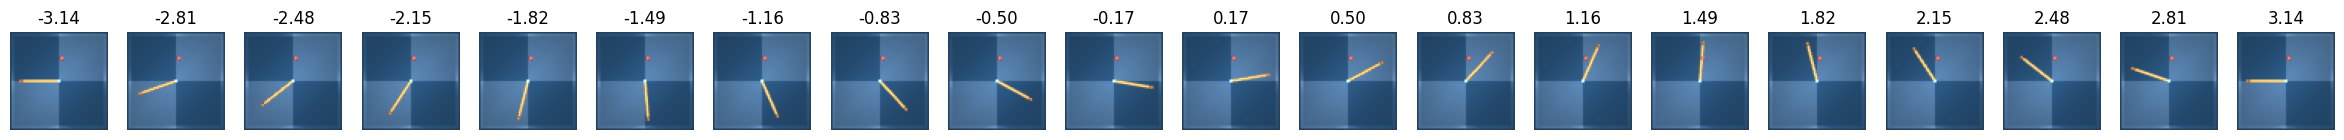

In [42]:
import matplotlib.pyplot as plt

env.reset()
# 1 - sample position uniformelly distributed along one axis of the workspace
x_pos = np.linspace(-3.14, 3.14, num=20)

# 2 - Get observations from the environment with the sampled position
pos_dict = {}
for pos in x_pos:
    print(pos)
    env.set_goal_state([pos, 0])
    pos_dict[pos] = env.step([0,0])
    

# 2.a - debug: plot the rgb observations
fig, ax = plt.subplots(1, len(pos_dict), figsize=(30, 10))
for i in range(len(pos_dict)):
    ax[i].imshow(pos_dict[x_pos[i]]["rgb"].transpose(1,2,0))
    ax[i].set_title(f"{x_pos[i]:.2f}")
    ax[i].axis('off')    
    

In [43]:
obs = env.reset()
meta = agent.init_meta()
step, total_reward = 0, 0
agent_state = None
eval_mode = False
# start-up agent with one env episode
with torch.no_grad():
        while not bool(obs['is_last']):
            action, agent_state = agent.act(
                                    obs,
                                    meta,
                                    step,
                                    eval_mode=eval_mode,
                                    state=agent_state,
                                )
            obs = env.step(action)
            
            feat = agent.wm.rssm.get_feat(agent_state[0]).unsqueeze(0)
            

In [44]:
# 3- Feed observations to the encoder and get object features, collect features in a list
feat = []
act_feat = []
obj_feat = []
agent_state = None
env.reset()

for pos, obs in pos_dict.items():
    # obs = torch.from_numpy(obs["rgb"].copy()).unsqueeze(0).float().to(agent.device)
    tensor_obs = {
            k: torch.as_tensor(np.copy(v), device=agent.device).unsqueeze(0)
            for k, v in obs.items()
        }
    
    with torch.no_grad():
        f = agent.wm.encoder(agent.wm.preprocess(tensor_obs))
        feat.append(f.cpu().numpy()[0])
        
        _, agent_state = agent.act(
                        obs,
                        meta,
                        0,
                        eval_mode=eval_mode,
                        state=agent_state)
        
        print(agent_state[1])
        # agent_state = (agent_state[0], torch.tensor(pos))
        # should update the agent state with the action that lead to the next state, otherwise, 
        # rssm expects to have a continuity betweeen consenquent state|action pairs
        
        a_f = agent.wm.rssm.get_feat(agent_state[0]).unsqueeze(0)
        act_feat.append(a_f.cpu().numpy()[0])
        
        o_f = agent.wm.heads["object_decoder"].object_latent_extractor(a_f)["post"]["mean"]
        obj_feat.append(o_f.cpu().numpy()[0])
            
feat, act_feat, obj_feat = np.array(feat), np.array(act_feat)[:,0], np.array(obj_feat)[:,0,0]

print(feat.shape)
print(act_feat.shape)
print(obj_feat.shape)

/opt/conda/lib/python3.11/site-packages/transformers/modeling_utils.py:907: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/torch/utils/checkpoint.py:31: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn("None of the inputs have requires_grad=True. Gradients will be None")
/mnt/home/focus/env/tracker/base_tracker.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, device=self.device)


tensor([[1.0000, 1.0000]], device='cuda:0')
tensor([[1.0000, 0.0288]], device='cuda:0')
tensor([[0.2850, 0.0958]], device='cuda:0')
tensor([[ 1.0000, -1.0000]], device='cuda:0')
tensor([[1.0000, 1.0000]], device='cuda:0')
tensor([[ 0.2649, -1.0000]], device='cuda:0')
tensor([[-0.5279,  1.0000]], device='cuda:0')
tensor([[0.1162, 0.9156]], device='cuda:0')
tensor([[ 1.0000, -0.0277]], device='cuda:0')
tensor([[-1.0000,  1.0000]], device='cuda:0')
tensor([[1.0000, 1.0000]], device='cuda:0')
tensor([[-1.0000,  1.0000]], device='cuda:0')
tensor([[-1.0000,  0.6046]], device='cuda:0')
tensor([[-1.0000,  1.0000]], device='cuda:0')
tensor([[1.0000, 1.0000]], device='cuda:0')
tensor([[ 0.0445, -0.7755]], device='cuda:0')
tensor([[0.4335, 0.3322]], device='cuda:0')
tensor([[-0.5758,  1.0000]], device='cuda:0')
tensor([[-1.0000,  0.8783]], device='cuda:0')
tensor([[0.7493, 1.0000]], device='cuda:0')
(20, 1936)
(20, 1224)
(20, 1536)


In [45]:
# 4 - t-SNE plot the features
from sklearn.manifold import TSNE
feat_embedded = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=3).fit_transform(feat)
act_feat_embedded = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=3).fit_transform(act_feat)
obj_feat_embedded = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=3).fit_transform(obj_feat)

Text(0.5, 1.0, 'Object features')

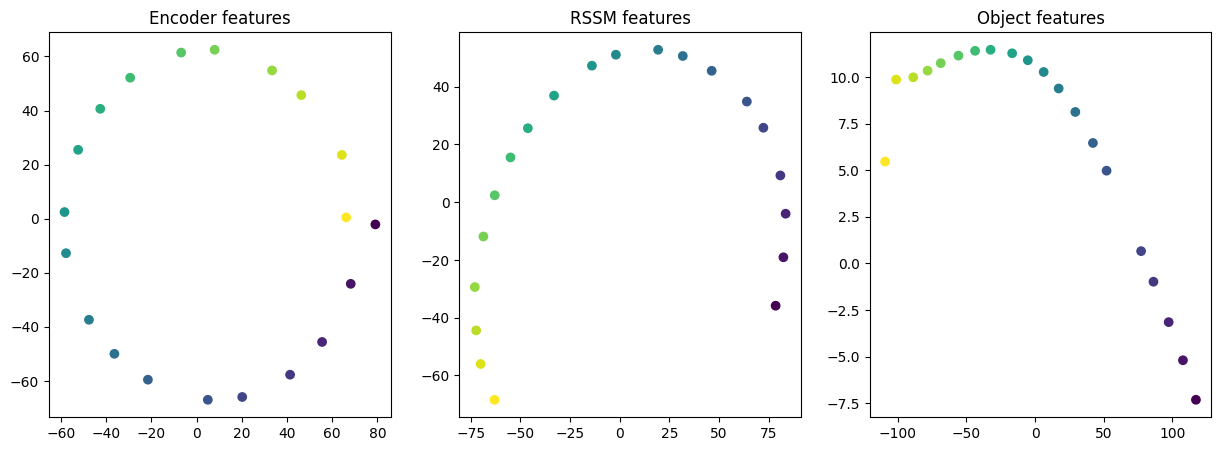

In [46]:
# 5 - associate each feature with a color that depens on the position along one axis

pos_list = np.fromiter(pos_dict.keys(), dtype=float)

# color_list = []
# for items in pos_dict.values():
    # color_list.append([0, *list((items["objects_pos"][0]))])
    
# print(color_list)
# print(color_list.shape)
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].scatter(feat_embedded[:,0], feat_embedded[:,1], c=pos_list)
axs[0].set_title("Encoder features")
axs[1].scatter(act_feat_embedded[:,0], act_feat_embedded[:,1], c=pos_list)
axs[1].set_title("RSSM features")
axs[2].scatter(obj_feat_embedded[:,0], obj_feat_embedded[:,1], c=pos_list)
axs[2].set_title("Object features")

{'encoder features': tensor([65.9291, 37.5606, 34.7340, 31.2141, 28.3703, 22.9476, 22.2275, 18.7281, 14.6476, 11.3577, 10.8100,  8.5674,  6.9444,  5.7955,  5.6970,  4.9397,  3.4064,  2.8334,  2.4662,  1.5460]), 'RSSM features': tensor([27.5701, 18.7340, 11.0455,  8.2498,  7.7325,  5.5156,  4.8849,  4.3936,  4.0418,  3.5744,  3.2201,  2.8542,  2.6530,  2.4811,  2.4075,  2.2157,  1.9991,  1.7822,  1.7264,  1.1296]), 'object features': tensor([34.3837, 23.0336, 18.7845, 12.0428,  6.5235,  3.1926,  2.8271,  2.1292,  1.3833,  1.1933,  1.0989,  0.7334,  0.6761,  0.5925,  0.4964,  0.3942,  0.2840,  0.2463,  0.1858,  0.1335])}


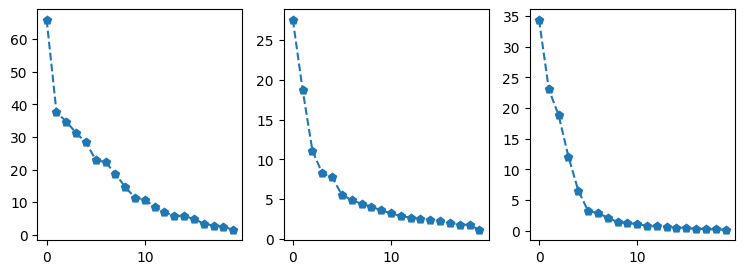

In [47]:
# Check relevant axis for position in the object's features -> ablation to check if there are major axis that are relevant for the position
d = {}

_, d["encoder features"], _ = torch.svd(torch.tensor(feat), compute_uv=False)
_, d["RSSM features"], _ = torch.svd(torch.tensor(act_feat), compute_uv=False)
_, d["object features"], _ = torch.svd(torch.tensor(obj_feat), compute_uv=False)

print(d)
fig, axs = plt.subplots(1, 3, figsize=(3*3,3))

axs[0].plot(d["encoder features"][:20], marker=(5, 0), linestyle='--')
axs[1].plot(d["RSSM features"][:20], marker=(5, 0), linestyle='--')
axs[2].plot(d["object features"][:20], marker=(5, 0), linestyle='--')

# TSNE only relative to those features

In [48]:
# 3- Feed observations to the encoder and get object features, collect features in a list
feat = []
act_feat = []
obj_feat = []
rgb_video = []
obs = env.reset()
rgb_video.append(obs["rgb"].transpose(1,2,0))

meta = agent.init_meta()
step, total_reward = 0, 0
agent_state = None
eval_mode = True
obj_pos_list = []

# start-up agent with one env episode
with torch.no_grad():
    while not bool(obs['is_last']):
        # obs = torch.from_numpy(obs["rgb"].copy()).unsqueeze(0).float().to(agent.device)
        tensor_obs = {
            k: torch.as_tensor(np.copy(v), device=agent.device).unsqueeze(0)
            for k, v in obs.items()
        }
    
        f = agent.wm.encoder(agent.wm.preprocess(tensor_obs))
        feat.append(f.cpu().numpy()[0])
        
        action, agent_state = agent.act(
                                obs,
                                meta,
                                step,
                                eval_mode=eval_mode,
                                state=agent_state,
                            )
        obs = env.step(action)
        obj_pos_list.append(obs["objects_pos"][0])
        rgb_video.append(obs["rgb"].transpose(1,2,0))
        
        # agent_state = (agent_state[0], torch.tensor(pos))
        # should update the agent state with the action that lead to the next state, otherwise, 
        # rssm expects to have a continuity betweeen consenquent state|action pairs
        
        a_f = agent.wm.rssm.get_feat(agent_state[0]).unsqueeze(0)
        act_feat.append(a_f.cpu().numpy()[0])
        
        o_f = agent.wm.heads["object_decoder"].object_latent_extractor(a_f)["post"]["mean"]
        obj_feat.append(o_f.cpu().numpy()[0])
            
feat, act_feat, obj_feat = np.array(feat), np.array(act_feat)[:,0], np.array(obj_feat)[:,0,0]
obj_pos_list, rgb_video = np.array(obj_pos_list), np.array(rgb_video)

print(feat.shape)
print(act_feat.shape)
print(obj_feat.shape)
print(obj_pos_list.shape)
print(rgb_video.shape)

/opt/conda/lib/python3.11/site-packages/transformers/modeling_utils.py:907: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/torch/utils/checkpoint.py:31: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn("None of the inputs have requires_grad=True. Gradients will be None")
/mnt/home/focus/env/tracker/base_tracker.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, device=self.device)


(125, 1936)
(125, 1224)
(125, 1536)
(125, 2)
(126, 64, 64, 3)


In [49]:

import imageio; 
from IPython.display import Video; 

imageio.mimwrite('test2.mp4', rgb_video, fps=30) 
# Video('test2.mp4', width=128, height=128)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


[[0.5083333, 0, 0.0], [0.39999998, 0, 0.03498542308807373], [0.27083334, 0, 0.09329450130462646], [0.14166667, 0, 0.1807580590248108], [0.045833364, 0, 0.29154515266418457], [0.0, 0, 0.41982507705688477], [0.01666667, 0, 0.5481049418449402], [0.09166669, 0, 0.6559766829013824], [0.20833334, 0, 0.7259475290775299], [0.33749998, 0, 0.7521866112947464], [0.3625, 0, 0.7988338470458984], [0.35833332, 0, 0.8658892214298248], [0.44583336, 0, 0.8717201352119446], [0.5, 0, 0.9125364571809769], [0.5458333, 0, 0.9708455093204975], [0.64166665, 0, 0.9504373259842396], [0.7291667, 0, 0.9650145918130875], [0.8125, 0, 1.0], [0.90416664, 0, 0.9446064308285713], [0.94583327, 0, 0.9504373259842396], [0.97499996, 0, 0.9008746519684792], [0.99583334, 0, 0.9154519215226173], [0.9583333, 0, 0.8979591950774193], [0.93749994, 0, 0.8454810529947281], [0.93333334, 0, 0.8746355772018433], [0.9583333, 0, 0.927113726735115], [0.93749994, 0, 0.9125364571809769], [0.92499995, 0, 0.8542274087667465], [0.92499995, 0, 

Text(0.5, 1.0, 'Object features')

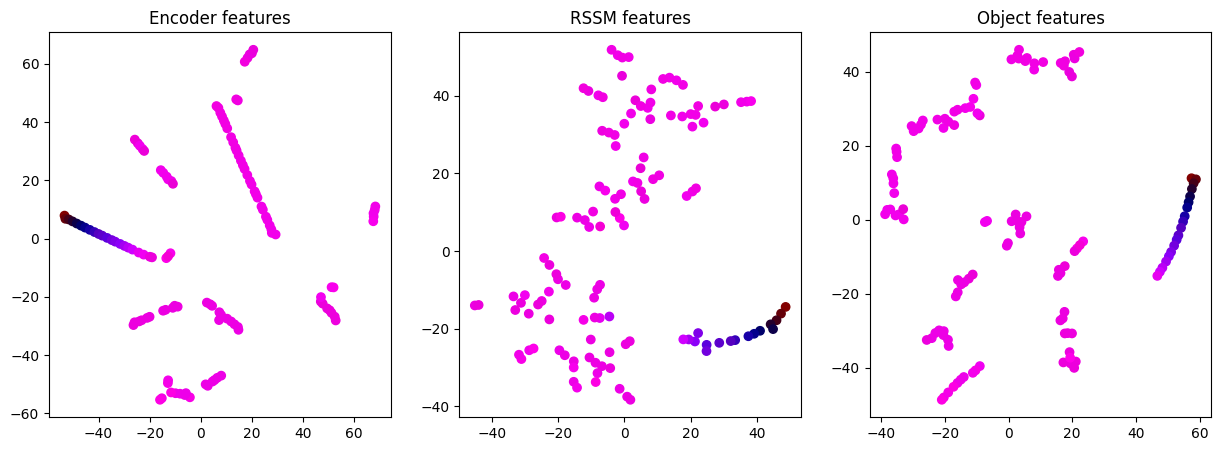

In [50]:
from sklearn.manifold import TSNE
feat_embedded = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=3).fit_transform(feat)
act_feat_embedded = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=3).fit_transform(act_feat)
obj_feat_embedded = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=3).fit_transform(obj_feat)
pos_list = np.linspace(-1, 1, num=feat.shape[0])

# normalize the position along the axis
norm_obj_pos_list = np.zeros_like(obj_pos_list)
norm_obj_pos_list[:,0] = (obj_pos_list[:,0] - obj_pos_list[:,0].min()) / (obj_pos_list[:,0].max() - obj_pos_list[:,0].min())
norm_obj_pos_list[:,1] = (obj_pos_list[:,1] - obj_pos_list[:,1].min()) / (obj_pos_list[:,1].max() - obj_pos_list[:,1].min())

color = []
for i in range(feat.shape[0]):
    color.append([norm_obj_pos_list[i][0], 0, 1-norm_obj_pos_list[i][1]])
print(color)

fig, axs = plt.subplots(1, 3, figsize=(15, 5)) #, subplot_kw=dict(projection='3d'))
axs[0].scatter(feat_embedded[:,0], feat_embedded[:,1], c=color)
axs[0].set_title("Encoder features")
axs[1].scatter(act_feat_embedded[:,0], act_feat_embedded[:,1], c=color)
axs[1].set_title("RSSM features")
axs[2].scatter(obj_feat_embedded[:,0], obj_feat_embedded[:,1], c=color)
axs[2].set_title("Object features")

{'encoder features': tensor([2.9422e+02, 8.5973e+01, 6.0153e+01, 3.9506e+01, 2.5295e+01, 2.2699e+01, 1.4082e+01, 9.6880e+00, 9.0221e+00, 7.4947e+00, 5.4047e+00, 4.5688e+00, 3.9353e+00, 3.6278e+00, 3.0327e+00, 2.8965e+00, 2.4570e+00, 2.3368e+00, 2.1526e+00, 2.0309e+00, 1.8703e+00, 1.7605e+00, 1.6842e+00, 1.5973e+00, 1.4770e+00, 1.4158e+00,
        1.2850e+00, 1.2354e+00, 1.1502e+00, 1.0461e+00, 9.3517e-01, 9.0965e-01, 8.8090e-01, 7.6287e-01, 6.3179e-01, 6.1150e-01, 5.6434e-01, 5.3415e-01, 5.1659e-01, 4.6483e-01, 4.4336e-01, 4.2207e-01, 4.0439e-01, 3.7060e-01, 3.4519e-01, 3.3741e-01, 3.1433e-01, 3.0474e-01, 2.6770e-01, 2.5102e-01, 2.3840e-01, 2.3040e-01,
        2.2256e-01, 2.1544e-01, 1.9778e-01, 1.8977e-01, 1.8212e-01, 1.7123e-01, 1.6358e-01, 1.5771e-01, 1.5237e-01, 1.3860e-01, 1.3457e-01, 1.3278e-01, 1.2998e-01, 1.2089e-01, 1.1426e-01, 1.1298e-01, 1.1017e-01, 1.0138e-01, 9.6777e-02, 9.2251e-02, 8.7078e-02, 8.4084e-02, 7.7544e-02, 7.6495e-02, 7.2805e-02, 7.0226e-02,
        6.3887e-02,

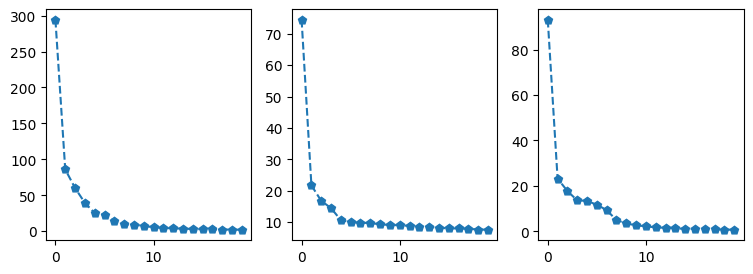

In [51]:
# Check relevant axis for position in the object's features -> ablation to check if there are major axis that are relevant for the position
d = {}

_, d["encoder features"], _ = torch.svd(torch.tensor(feat), compute_uv=False)
_, d["RSSM features"], _ = torch.svd(torch.tensor(act_feat), compute_uv=False)
_, d["object features"], _ = torch.svd(torch.tensor(obj_feat), compute_uv=False)

print(d)
fig, axs = plt.subplots(1, 3, figsize=(3*3,3))

axs[0].plot(d["encoder features"][:20], marker=(5, 0), linestyle='--')
axs[1].plot(d["RSSM features"][:20], marker=(5, 0), linestyle='--')
axs[2].plot(d["object features"][:20], marker=(5, 0), linestyle='--')

# TSNE only relative to those features